# Experiment: Replace NNLS rough draft with unconstrained LS (lstsq)

**Question**: V8 trained on NNLS rough drafts (spiky 0/1 garbage on broad spectra) + raw measurements achieved test MSE 0.00659. If we swap NNLS for `lstsq` (unconstrained LS, gives smooth-but-possibly-negative drafts), keeping everything else identical, does the network do better, worse, or the same?

**Why care**: tells us whether the network's improvement comes from *refining the NNLS draft* or from the *raw 25-d input* (V4's contribution). If lstsq drafts work as well or better, NNLS is doing nothing useful for us.

**Setup**: identical to V8/V9 (V5 architecture, AdamW + cosine LR, early stopping, 5183 train / 296 test, Huber loss). Only the rough-draft input changes.

**Direct comparison numbers**:
- V8 (NNLS draft + raw, MSE loss): **0.00659**
- V9 (NNLS draft + raw, Huber loss): **0.00649**
- This experiment (lstsq draft + raw, Huber loss): **?**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

wavelengths = np.linspace(1550, 1565, 1500)
torch.manual_seed(0)  # reproducibility for the NN training

In [2]:
# --- Load everything ---
X_train_np   = np.load('data/X_train_np.npy')                # (3000, 25) raw measurements
y_train_np   = np.load('data/y_train_np.npy')                # (3000, 1500) ground truth
labels_list  = np.load('data/labels_list.npy', allow_pickle=True)

# NNLS broad-only rough drafts (the V8 input)
X_rough_nnls_broad     = np.load('data/X_train_rough_broad_alpha50000.npy')
nnls_indices           = np.load('data/X_train_rough_broad_alpha50000_indices.npy')

# lstsq broad-only rough drafts (THE NEW INPUT)
X_rough_lstsq_broad    = np.load('data/X_train_rough_broad_lstsq_alpha50000.npy')
lstsq_indices          = np.load('data/X_train_rough_broad_lstsq_alpha50000_indices.npy')

# Extra broad samples (for the V8-style 'more data' setup)
X_train_np_extra       = np.load('data/X_train_np_broad_extra.npy')
y_train_np_extra       = np.load('data/y_train_np_broad_extra.npy')

# Normalization stats (for raw 25-d measurements)
norm_mean = np.load('data/normalization_mean.npy')
norm_std  = np.load('data/normalization_std.npy')

print(f'Raw measurements:   {X_train_np.shape}')
print(f'Ground truth:       {y_train_np.shape}')
print(f'NNLS broad drafts:  {X_rough_nnls_broad.shape}  (alpha=50000, clipped [0,1])')
print(f'lstsq broad drafts: {X_rough_lstsq_broad.shape}  (alpha=50000, no clipping, can be negative)')
print(f'Extra broad:        raw={X_train_np_extra.shape}, gt={y_train_np_extra.shape}')

# Sanity: lstsq drafts can have negatives; NNLS clipped to [0,1]
print(f'\nNNLS draft  range: [{X_rough_nnls_broad.min():.3f}, {X_rough_nnls_broad.max():.3f}]')
print(f'lstsq draft range: [{X_rough_lstsq_broad.min():.3f}, {X_rough_lstsq_broad.max():.3f}]  <-- expect negatives')

Raw measurements:   (3000, 25)
Ground truth:       (3000, 1500)
NNLS broad drafts:  (1479, 1500)  (alpha=50000, clipped [0,1])
lstsq broad drafts: (1479, 1500)  (alpha=50000, no clipping, can be negative)
Extra broad:        raw=(4000, 25), gt=(4000, 1500)

NNLS draft  range: [0.000, 9.142]
lstsq draft range: [-7.305, 7.825]  <-- expect negatives


In [3]:
# --- Sanity check: lstsq and NNLS broad files use the same sample ordering ---
# Both index files should be the broad-sample indices into the full 3000-sample set.
broad_types = {'generate_broad_emission', 'generate_broad_absorption'}
broad_mask = np.array([lbl in broad_types for lbl in labels_list])
expected_indices = np.where(broad_mask)[0]

assert np.array_equal(nnls_indices, expected_indices),  'NNLS file ordering does not match broad_mask'
assert np.array_equal(lstsq_indices, expected_indices), 'lstsq file ordering does not match broad_mask'
assert np.array_equal(nnls_indices, lstsq_indices),     'NNLS and lstsq files have different indices'
print(f'OK: both rough draft files cover the same {len(expected_indices)} broad samples.')

OK: both rough draft files cover the same 1479 broad samples.


## Generate lstsq rough drafts for the 4000 extra samples

We have NNLS rough drafts for the extras (`X_train_rough_broad_extra_alpha50000.npy`) but not lstsq. Since lstsq is a closed-form batched solve, this takes seconds. Saved to disk so it's idempotent.

In [4]:
EXTRA_ALPHA = 50000  # match the existing files
extra_lstsq_path = f'data/X_train_rough_broad_extra_lstsq_alpha{EXTRA_ALPHA}.npy'

if os.path.exists(extra_lstsq_path):
    print(f'Loading existing extras: {extra_lstsq_path}')
    X_rough_lstsq_extra = np.load(extra_lstsq_path)
else:
    print(f'Generating lstsq rough drafts for {len(X_train_np_extra)} extra samples...')
    # Load calibration matrix (same path as generate_data.ipynb)
    T = scipy.io.loadmat(
        '/Users/jatinvirmatharoo/Documents/Spectrometer URA/transmission_matrices/Matrix_calabration_Dis7.mat'
    )['mat2']
    print(f'Calibration matrix T: {T.shape}')

    # First-order difference matrix L for smoothness regularization
    n = 1500
    L = np.zeros((n - 1, n))
    for i in range(n - 1):
        L[i, i] = -1
        L[i, i + 1] = 1
    T_aug = np.vstack([T, np.sqrt(EXTRA_ALPHA) * L])  # (1524, 1500)

    # Batched solve: 4000 RHS in one call. Closed-form, fast.
    measurements = X_train_np_extra.T                     # (25, 4000)
    zeros_pad    = np.zeros((1499, len(X_train_np_extra)))  # (1499, 4000)
    y_augs       = np.vstack([measurements, zeros_pad])   # (1524, 4000)

    sol, *_ = np.linalg.lstsq(T_aug, y_augs, rcond=None)
    X_rough_lstsq_extra = sol.T                           # (4000, 1500)

    np.save(extra_lstsq_path, X_rough_lstsq_extra)
    print(f'Saved {X_rough_lstsq_extra.shape} -> {extra_lstsq_path}')

extra_input_mse = np.mean((X_rough_lstsq_extra - y_train_np_extra) ** 2)
print(f'\nExtra lstsq drafts input MSE vs ground truth: {extra_input_mse:.6f}')
print(f'(For reference, NNLS extras MSE was ~0.078 — lstsq input quality is the first thing to compare)')

Generating lstsq rough drafts for 4000 extra samples...
Calibration matrix T: (25, 1500)
Saved (4000, 1500) -> data/X_train_rough_broad_extra_lstsq_alpha50000.npy

Extra lstsq drafts input MSE vs ground truth: 0.367191
(For reference, NNLS extras MSE was ~0.078 — lstsq input quality is the first thing to compare)


NNLS broad input MSE:   mean=0.1798, median=0.0559, worst=2.1180
lstsq broad input MSE:  mean=0.3375, median=0.0662, worst=8.7684


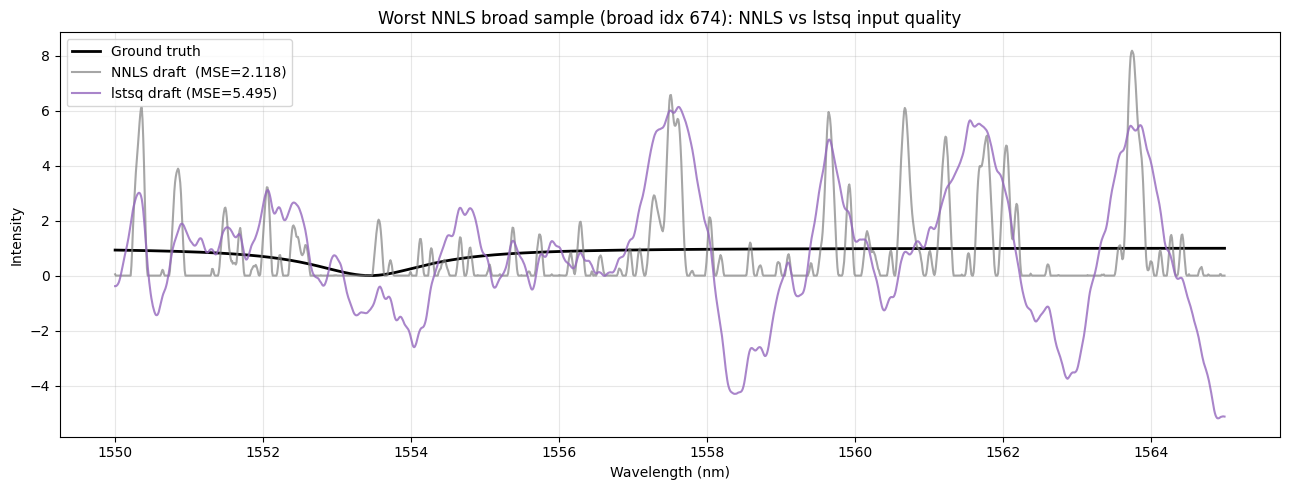

In [5]:
# --- Visual sanity: NNLS draft vs lstsq draft on a few samples ---
# Pick the broad sample with worst NNLS MSE so we see the dramatic case
y_broad        = y_train_np[broad_mask]
nnls_per_samp  = np.mean((X_rough_nnls_broad  - y_broad) ** 2, axis=1)
lstsq_per_samp = np.mean((X_rough_lstsq_broad - y_broad) ** 2, axis=1)

print(f'NNLS broad input MSE:   mean={nnls_per_samp.mean():.4f}, median={np.median(nnls_per_samp):.4f}, worst={nnls_per_samp.max():.4f}')
print(f'lstsq broad input MSE:  mean={lstsq_per_samp.mean():.4f}, median={np.median(lstsq_per_samp):.4f}, worst={lstsq_per_samp.max():.4f}')

worst_idx = int(np.argmax(nnls_per_samp))
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(wavelengths, y_broad[worst_idx],            label='Ground truth', color='black', linewidth=2)
ax.plot(wavelengths, X_rough_nnls_broad[worst_idx], label=f'NNLS draft  (MSE={nnls_per_samp[worst_idx]:.3f})', color='gray', alpha=0.7)
ax.plot(wavelengths, X_rough_lstsq_broad[worst_idx], label=f'lstsq draft (MSE={lstsq_per_samp[worst_idx]:.3f})', color='tab:purple', alpha=0.8)
ax.set_title(f'Worst NNLS broad sample (broad idx {worst_idx}): NNLS vs lstsq input quality')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Intensity')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstsq_vs_nnls_input.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Broad-only ground truth and raw measurements
y_broad_true = y_train_np[broad_mask]
X_raw_broad  = X_train_np[broad_mask]

# Identical split to V8 (random_state=42 on broad-only)
X_rough_lstsq_train, X_rough_lstsq_test = train_test_split(X_rough_lstsq_broad, test_size=0.2, random_state=42)
X_raw_train,         X_raw_test         = train_test_split(X_raw_broad,         test_size=0.2, random_state=42)
y_train,             y_test             = train_test_split(y_broad_true,        test_size=0.2, random_state=42)

# Append the 4000 extra samples to TRAINING ONLY (test set unchanged for fair comparison)
X_rough_lstsq_train_full = np.concatenate([X_rough_lstsq_train, X_rough_lstsq_extra], axis=0)
X_raw_train_full         = np.concatenate([X_raw_train,         X_train_np_extra],     axis=0)
y_train_full             = np.concatenate([y_train,             y_train_np_extra],     axis=0)

# Normalize raw 25-d measurements with the SAME stats used elsewhere
X_raw_train_full_norm = (X_raw_train_full - norm_mean) / norm_std
X_raw_test_norm       = (X_raw_test       - norm_mean) / norm_std

print(f'Training:  {len(X_rough_lstsq_train_full)} samples (1183 base + 4000 extra)')
print(f'Test:      {len(X_rough_lstsq_test)} samples (same as V8/V9 in main.ipynb)')

Training:  5183 samples (1183 base + 4000 extra)
Test:      296 samples (same as V8/V9 in main.ipynb)


In [7]:
# Same dataset shape as main.ipynb's BroadSpectrumDatasetV2 (rough + raw + target)
class BroadSpectrumDatasetV2(Dataset):
    def __init__(self, X_rough, X_raw, y):
        self.X_rough = torch.from_numpy(X_rough).float()
        self.X_raw   = torch.from_numpy(X_raw).float()
        self.y       = torch.from_numpy(y).float()
    def __len__(self):
        return len(self.X_rough)
    def __getitem__(self, idx):
        return self.X_rough[idx], self.X_raw[idx], self.y[idx]

train_dataset = BroadSpectrumDatasetV2(X_rough_lstsq_train_full, X_raw_train_full_norm, y_train_full)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)
print(f'Batches per epoch: {len(train_loader)}')

Batches per epoch: 162


In [8]:
# Same V5 architecture used by V5/V6/V7/V8/V9 in main.ipynb
class BroadSolverNetworkV5(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(1525, 1024)   # 1500 (rough) + 25 (raw) = 1525
        self.layer2 = nn.Linear(1024, 512)
        self.layer3 = nn.Linear(512, 1500)
        self.ReLU = nn.ReLU()
    def forward(self, x_rough, x_raw):
        x = torch.cat([x_rough, x_raw], dim=1)
        x = self.ReLU(self.layer1(x))
        x = self.ReLU(self.layer2(x))
        x = self.layer3(x)
        return x

In [9]:
# Same Huber + amplitude-weighted loss as V9 (the best variant)
def broad_loss_huber(pred, target, smoothness_lambda=0.1, amp_alpha=2.0, delta=0.1):
    weight = 1.0 + amp_alpha * target
    huber_per_elem = F.huber_loss(pred, target, reduction='none', delta=delta)
    recon = torch.mean(weight * huber_per_elem)
    smooth = torch.mean((pred[:, 1:] - pred[:, :-1]) ** 2)
    return recon + smoothness_lambda * smooth

In [10]:
# --- Training: V8/V9 recipe exactly (AdamW + cosine LR + early-stop best snapshot) ---
model     = BroadSolverNetworkV5()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
num_epochs = 400
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

X_rough_test_tensor = torch.from_numpy(X_rough_lstsq_test).float()
X_raw_test_tensor   = torch.from_numpy(X_raw_test_norm).float()
y_test_tensor       = torch.from_numpy(y_test).float()

train_losses, val_mses, epochs_recorded = [], [], []
best_val_mse, best_state, best_epoch = float('inf'), None, -1

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for batch_rough, batch_raw, batch_y in train_loader:
        predicted = model(batch_rough, batch_raw)
        loss = broad_loss_huber(predicted, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    avg_train_loss = epoch_loss / len(train_loader)

    if (epoch + 1) % 20 == 0:
        model.eval()
        with torch.no_grad():
            val_pred = model(X_rough_test_tensor, X_raw_test_tensor)
            val_mse  = torch.mean((val_pred - y_test_tensor) ** 2).item()
        improved = ''
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_state   = {k: v.detach().clone() for k, v in model.state_dict().items()}
            best_epoch   = epoch + 1
            improved = '  <-- new best'
        train_losses.append(avg_train_loss)
        val_mses.append(val_mse)
        epochs_recorded.append(epoch + 1)
        lr = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch+1:3d}/{num_epochs}  Train(Huber)={avg_train_loss:.6f}  Test MSE={val_mse:.6f}  LR={lr:.2e}{improved}')

model.load_state_dict(best_state)
print(f'\nRestored best model from epoch {best_epoch}, test MSE = {best_val_mse:.6f}')

Epoch  20/400  Train(Huber)=0.004215  Test MSE=0.005574  LR=9.94e-04  <-- new best
Epoch  40/400  Train(Huber)=0.003454  Test MSE=0.005664  LR=9.76e-04
Epoch  60/400  Train(Huber)=0.002957  Test MSE=0.005493  LR=9.46e-04  <-- new best
Epoch  80/400  Train(Huber)=0.002752  Test MSE=0.005728  LR=9.05e-04
Epoch 100/400  Train(Huber)=0.002607  Test MSE=0.005810  LR=8.54e-04
Epoch 120/400  Train(Huber)=0.002410  Test MSE=0.005898  LR=7.94e-04
Epoch 140/400  Train(Huber)=0.002290  Test MSE=0.006246  LR=7.27e-04
Epoch 160/400  Train(Huber)=0.002089  Test MSE=0.006084  LR=6.55e-04
Epoch 180/400  Train(Huber)=0.002024  Test MSE=0.006100  LR=5.78e-04
Epoch 200/400  Train(Huber)=0.001919  Test MSE=0.005966  LR=5.00e-04
Epoch 220/400  Train(Huber)=0.001792  Test MSE=0.006150  LR=4.22e-04
Epoch 240/400  Train(Huber)=0.001698  Test MSE=0.006164  LR=3.45e-04
Epoch 260/400  Train(Huber)=0.001610  Test MSE=0.006354  LR=2.73e-04
Epoch 280/400  Train(Huber)=0.001559  Test MSE=0.006406  LR=2.06e-04
Epoch 

In [11]:
# --- Evaluate + compare to V8/V9 ---
model.eval()
with torch.no_grad():
    predictions_lstsq = model(X_rough_test_tensor, X_raw_test_tensor).numpy()

mse_lstsq_model    = np.mean((predictions_lstsq - y_test) ** 2)
mse_nnls_input     = np.mean((X_rough_lstsq_test - y_test) ** 2)  # same test split, lstsq input quality
mse_nnls_input_old = 0.074441   # NNLS input MSE from main.ipynb (same test samples, NNLS draft)

print('=' * 60)
print(f'lstsq draft input MSE (test set):     {mse_nnls_input:.6f}')
print(f'NNLS  draft input MSE (test set):     {mse_nnls_input_old:.6f}  <-- from main.ipynb')
print('-' * 60)
print(f'V8 (NNLS  draft + raw, MSE loss):     0.006586')
print(f'V9 (NNLS  draft + raw, Huber loss):   0.006488')
print(f'THIS (lstsq draft + raw, Huber loss): {mse_lstsq_model:.6f}')
print('=' * 60)

if mse_lstsq_model < 0.006488:
    print(f'\nlstsq beats V9 by {(0.006488 - mse_lstsq_model)*1e6:.1f} ppm  -> NNLS draft was hurting')
elif mse_lstsq_model > 0.006488 * 1.05:
    print(f'\nlstsq is meaningfully worse than V9 -> NNLS draft was contributing real signal')
else:
    print(f'\nlstsq is within 5% of V9 -> NNLS draft adds little; raw 25-d input is doing most of the work')

lstsq draft input MSE (test set):     0.287687
NNLS  draft input MSE (test set):     0.074441  <-- from main.ipynb
------------------------------------------------------------
V8 (NNLS  draft + raw, MSE loss):     0.006586
V9 (NNLS  draft + raw, Huber loss):   0.006488
THIS (lstsq draft + raw, Huber loss): 0.005493

lstsq beats V9 by 995.4 ppm  -> NNLS draft was hurting


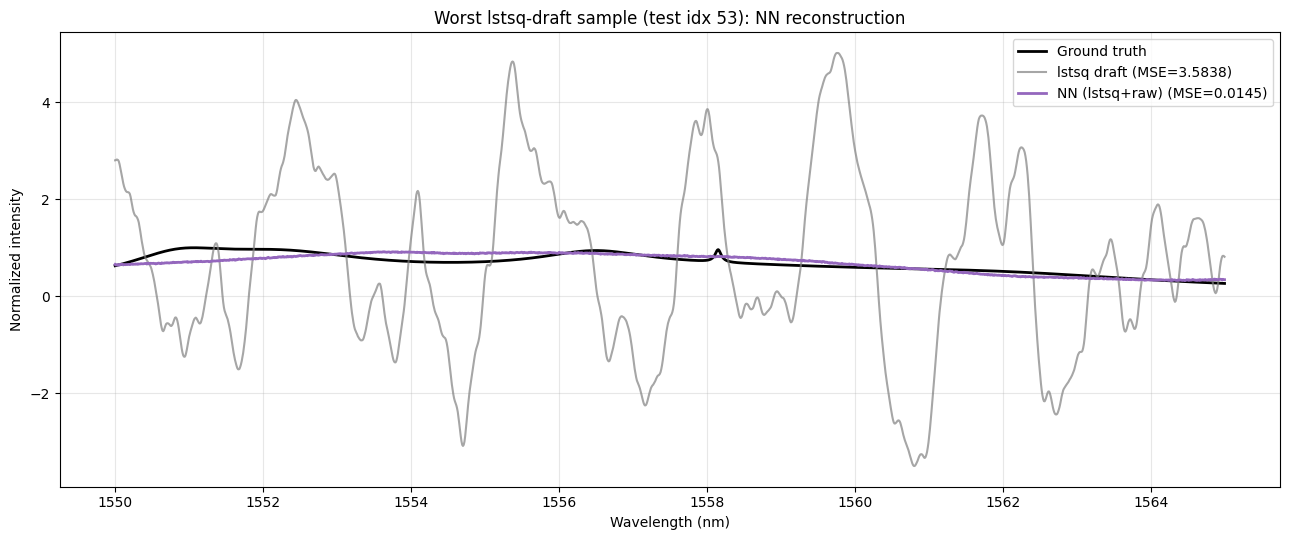

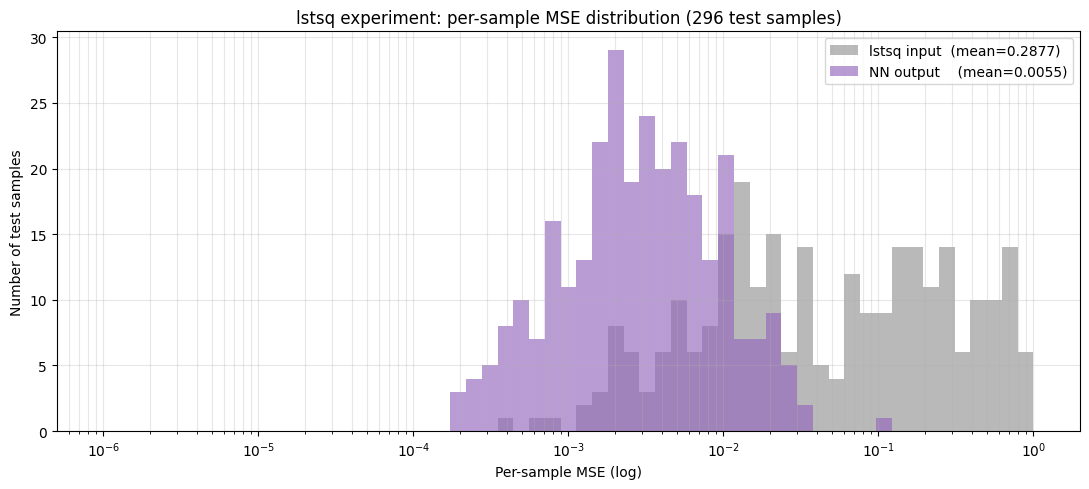

In [12]:
# --- Headline plot: same worst-NNLS sample, lstsq-trained model ---
# Reuse the test sample that was worst for NNLS in main.ipynb (test idx with max NNLS-input MSE)
mse_nnls_per_sample  = np.mean((X_rough_lstsq_test - y_test) ** 2, axis=1)  # NOTE: this is lstsq input MSE
mse_lstsq_per_sample = np.mean((predictions_lstsq  - y_test) ** 2, axis=1)
worst_idx = int(np.argmax(mse_nnls_per_sample))

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(wavelengths, y_test[worst_idx],            label='Ground truth',                                       color='black', linewidth=2)
ax.plot(wavelengths, X_rough_lstsq_test[worst_idx], label=f'lstsq draft (MSE={mse_nnls_per_sample[worst_idx]:.4f})', color='gray', alpha=0.7)
ax.plot(wavelengths, predictions_lstsq[worst_idx],  label=f'NN (lstsq+raw) (MSE={mse_lstsq_per_sample[worst_idx]:.4f})', color='tab:purple', linewidth=2)
ax.set_title(f'Worst lstsq-draft sample (test idx {worst_idx}): NN reconstruction')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Normalized intensity')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstsq_headline.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-sample distribution
fig, ax = plt.subplots(figsize=(11, 5))
bins = np.logspace(-6, 0, 60)
ax.hist(mse_nnls_per_sample,  bins=bins, alpha=0.55, label=f'lstsq input  (mean={mse_nnls_per_sample.mean():.4f})', color='gray')
ax.hist(mse_lstsq_per_sample, bins=bins, alpha=0.65, label=f'NN output    (mean={mse_lstsq_per_sample.mean():.4f})', color='tab:purple')
ax.set_xscale('log')
ax.set_xlabel('Per-sample MSE (log)')
ax.set_ylabel('Number of test samples')
ax.set_title('lstsq experiment: per-sample MSE distribution (296 test samples)')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('lstsq_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# --- Save predictions + best model so we can compare in main.ipynb later ---
np.save('data/predictions_lstsq.npy', predictions_lstsq)
torch.save(best_state, 'data/model_lstsq_best.pth')
print('Saved data/predictions_lstsq.npy and data/model_lstsq_best.pth')

Saved data/predictions_lstsq.npy and data/model_lstsq_best.pth


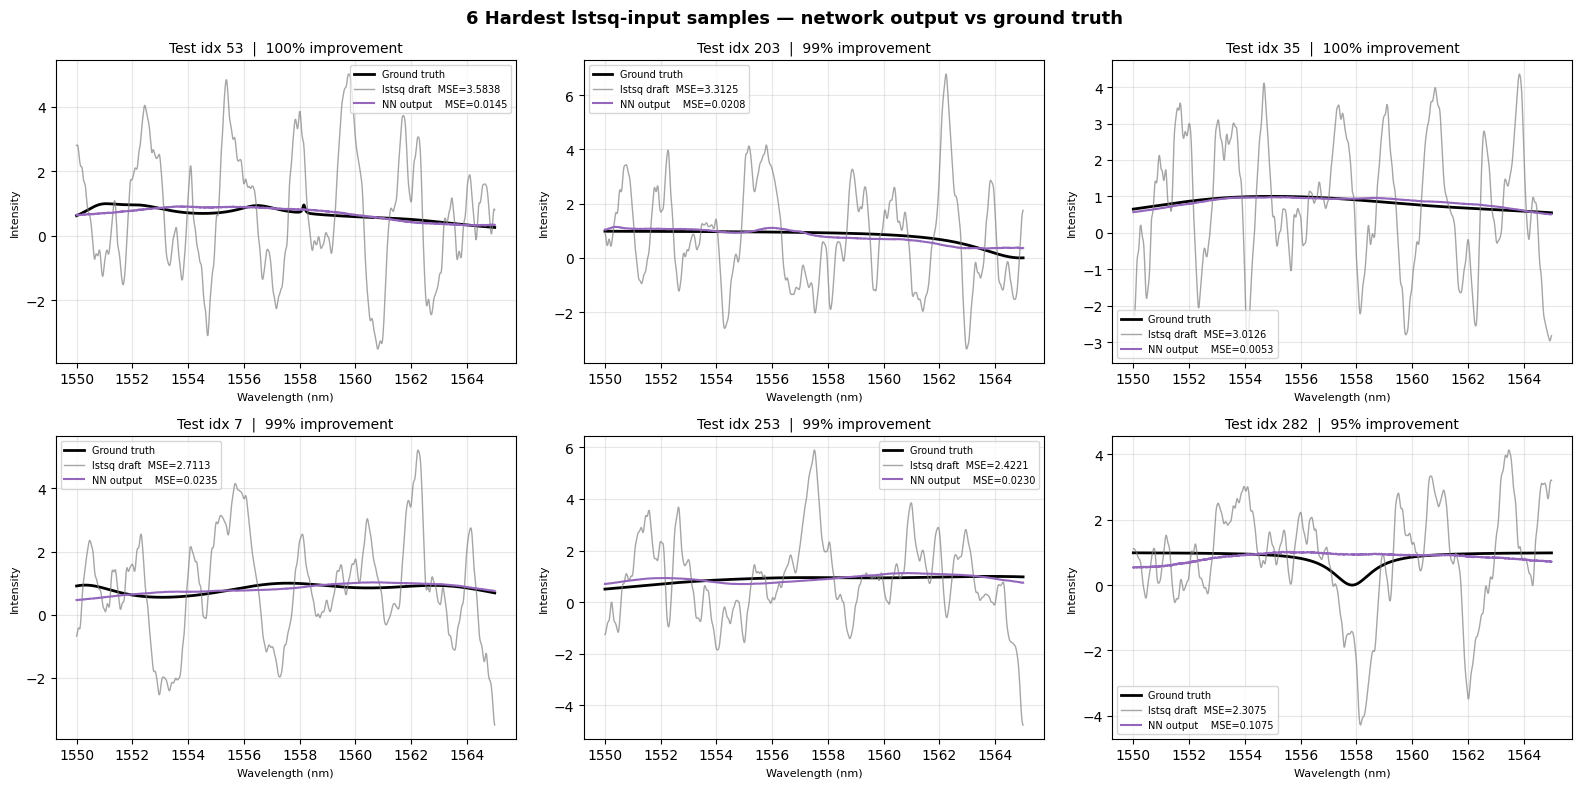

Saved lstsq_worst6_grid.png


In [21]:

# --- Plot 1: Worst-case grid ---
# 6 samples with the worst lstsq DRAFT MSE (hardest inputs).
# Shows: how does the network cope when the input is terrible?

predictions_lstsq = np.load('data/predictions_lstsq.npy')  # in case running fresh

mse_input_per  = np.mean((X_rough_lstsq_test - y_test) ** 2, axis=1)
mse_output_per = np.mean((predictions_lstsq  - y_test) ** 2, axis=1)

worst6 = np.argsort(mse_input_per)[-6:][::-1]  # 6 worst inputs, worst first

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for plot_i, test_idx in enumerate(worst6):
    ax = axes[plot_i]
    improvement = (mse_input_per[test_idx] - mse_output_per[test_idx]) / mse_input_per[test_idx] * 100
    ax.plot(wavelengths, y_test[test_idx],                color='black',      linewidth=2,   label='Ground truth')
    ax.plot(wavelengths, X_rough_lstsq_test[test_idx],    color='gray',       linewidth=1,   alpha=0.7, label=f'lstsq draft  MSE={mse_input_per[test_idx]:.4f}')
    ax.plot(wavelengths, predictions_lstsq[test_idx],     color='tab:purple', linewidth=1.5, label=f'NN output    MSE={mse_output_per[test_idx]:.4f}')
    ax.set_title(f'Test idx {test_idx}  |  {improvement:.0f}% improvement', fontsize=10)
    ax.set_xlabel('Wavelength (nm)', fontsize=8)
    ax.set_ylabel('Intensity', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle('6 Hardest lstsq-input samples — network output vs ground truth', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lstsq_worst6_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved lstsq_worst6_grid.png')


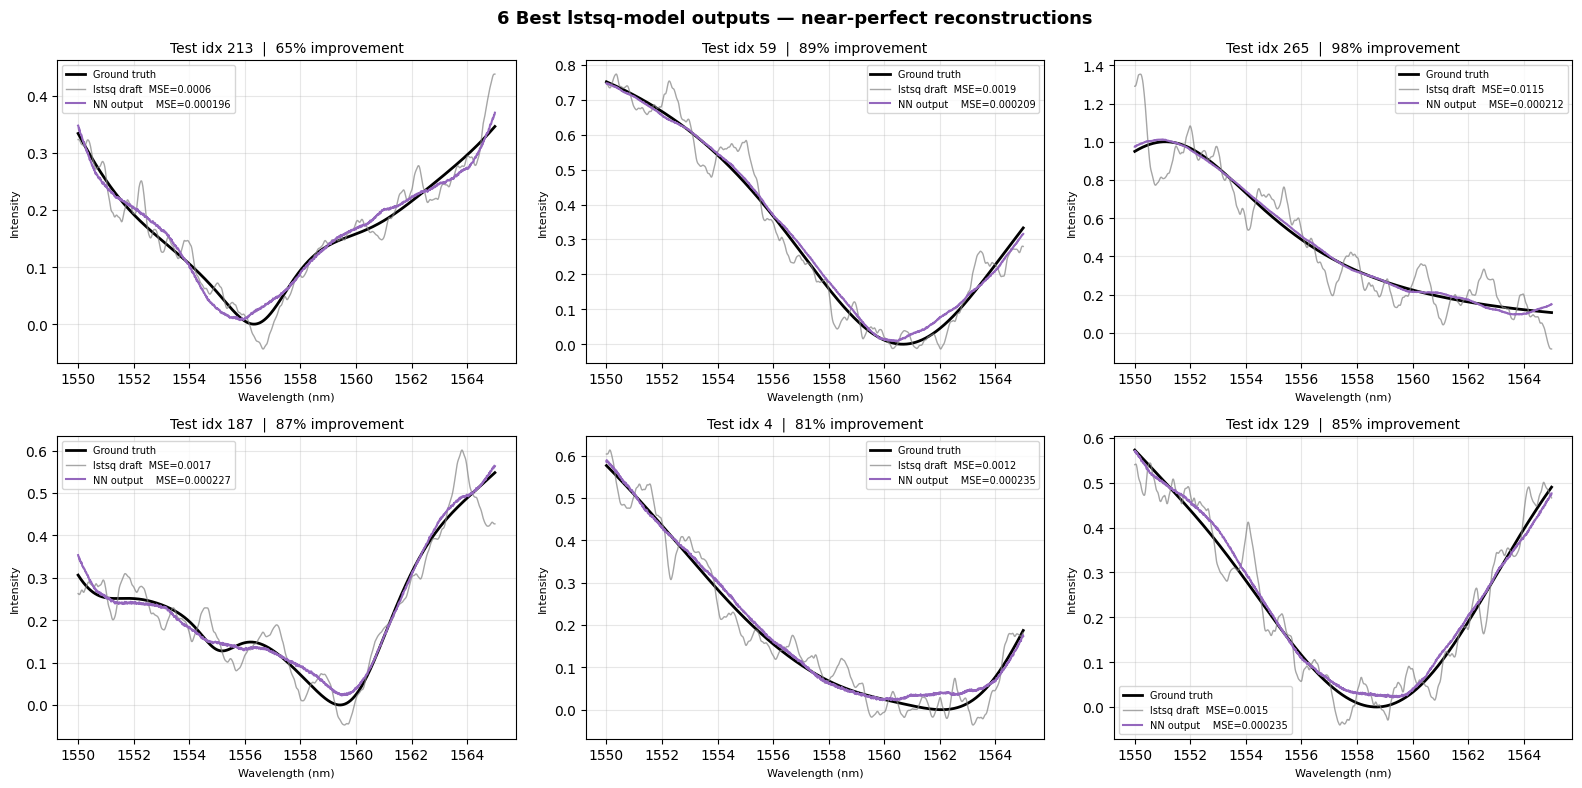

Saved lstsq_best6_grid.png


In [22]:

# --- Plot: Best-case grid ---
# 6 samples with the lowest NN output MSE (cleanest reconstructions).
# Shows: what does the network look like when it works perfectly?

best6 = np.argsort(mse_output_per)[:6]  # 6 best outputs, best first

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for plot_i, test_idx in enumerate(best6):
    ax = axes[plot_i]
    improvement = (mse_input_per[test_idx] - mse_output_per[test_idx]) / mse_input_per[test_idx] * 100
    ax.plot(wavelengths, y_test[test_idx],                color='black',      linewidth=2,   label='Ground truth')
    ax.plot(wavelengths, X_rough_lstsq_test[test_idx],    color='gray',       linewidth=1,   alpha=0.7, label=f'lstsq draft  MSE={mse_input_per[test_idx]:.4f}')
    ax.plot(wavelengths, predictions_lstsq[test_idx],     color='tab:purple', linewidth=1.5, label=f'NN output    MSE={mse_output_per[test_idx]:.6f}')
    ax.set_title(f'Test idx {test_idx}  |  {improvement:.0f}% improvement', fontsize=10)
    ax.set_xlabel('Wavelength (nm)', fontsize=8)
    ax.set_ylabel('Intensity', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle('6 Best lstsq-model outputs — near-perfect reconstructions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lstsq_best6_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved lstsq_best6_grid.png')


Network improved 97.0% of test samples (output MSE < input MSE)
Input  MSE: mean=0.28769, median=0.06468
Output MSE: mean=0.00549, median=0.00289


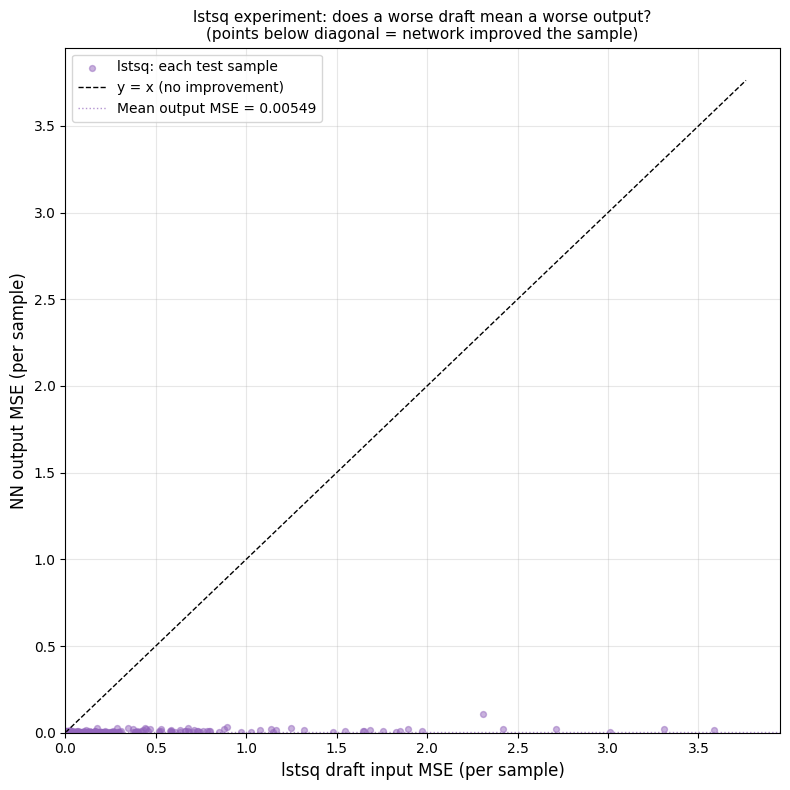

Saved lstsq_scatter.png


In [23]:

# --- Plot 2: Scatter — input MSE vs output MSE (per sample) ---
# Each dot = one test sample.
# X axis: how bad was the lstsq draft?
# Y axis: how good is the NN output?
# Diagonal reference line: output = input (no improvement).
# Points below the line = network helped. Further below = helped more.

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(mse_input_per, mse_output_per, alpha=0.5, s=18, color='tab:purple', label='lstsq: each test sample')

# Reference line: y = x (no improvement)
lim_max = max(mse_input_per.max(), mse_output_per.max()) * 1.05
ax.plot([0, lim_max], [0, lim_max], 'k--', linewidth=1, label='y = x (no improvement)')

# Annotate overall stats
ax.axhline(mse_output_per.mean(), color='tab:purple', linestyle=':', linewidth=1, alpha=0.7, label=f'Mean output MSE = {mse_output_per.mean():.5f}')

ax.set_xlabel('lstsq draft input MSE (per sample)', fontsize=12)
ax.set_ylabel('NN output MSE (per sample)', fontsize=12)
ax.set_title('lstsq experiment: does a worse draft mean a worse output?\n(points below diagonal = network improved the sample)', fontsize=11)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Fraction of samples where network helped
frac_helped = np.mean(mse_output_per < mse_input_per)
print(f'Network improved {frac_helped*100:.1f}% of test samples (output MSE < input MSE)')
print(f'Input  MSE: mean={mse_input_per.mean():.5f}, median={np.median(mse_input_per):.5f}')
print(f'Output MSE: mean={mse_output_per.mean():.5f}, median={np.median(mse_output_per):.5f}')

plt.tight_layout()
plt.savefig('lstsq_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved lstsq_scatter.png')


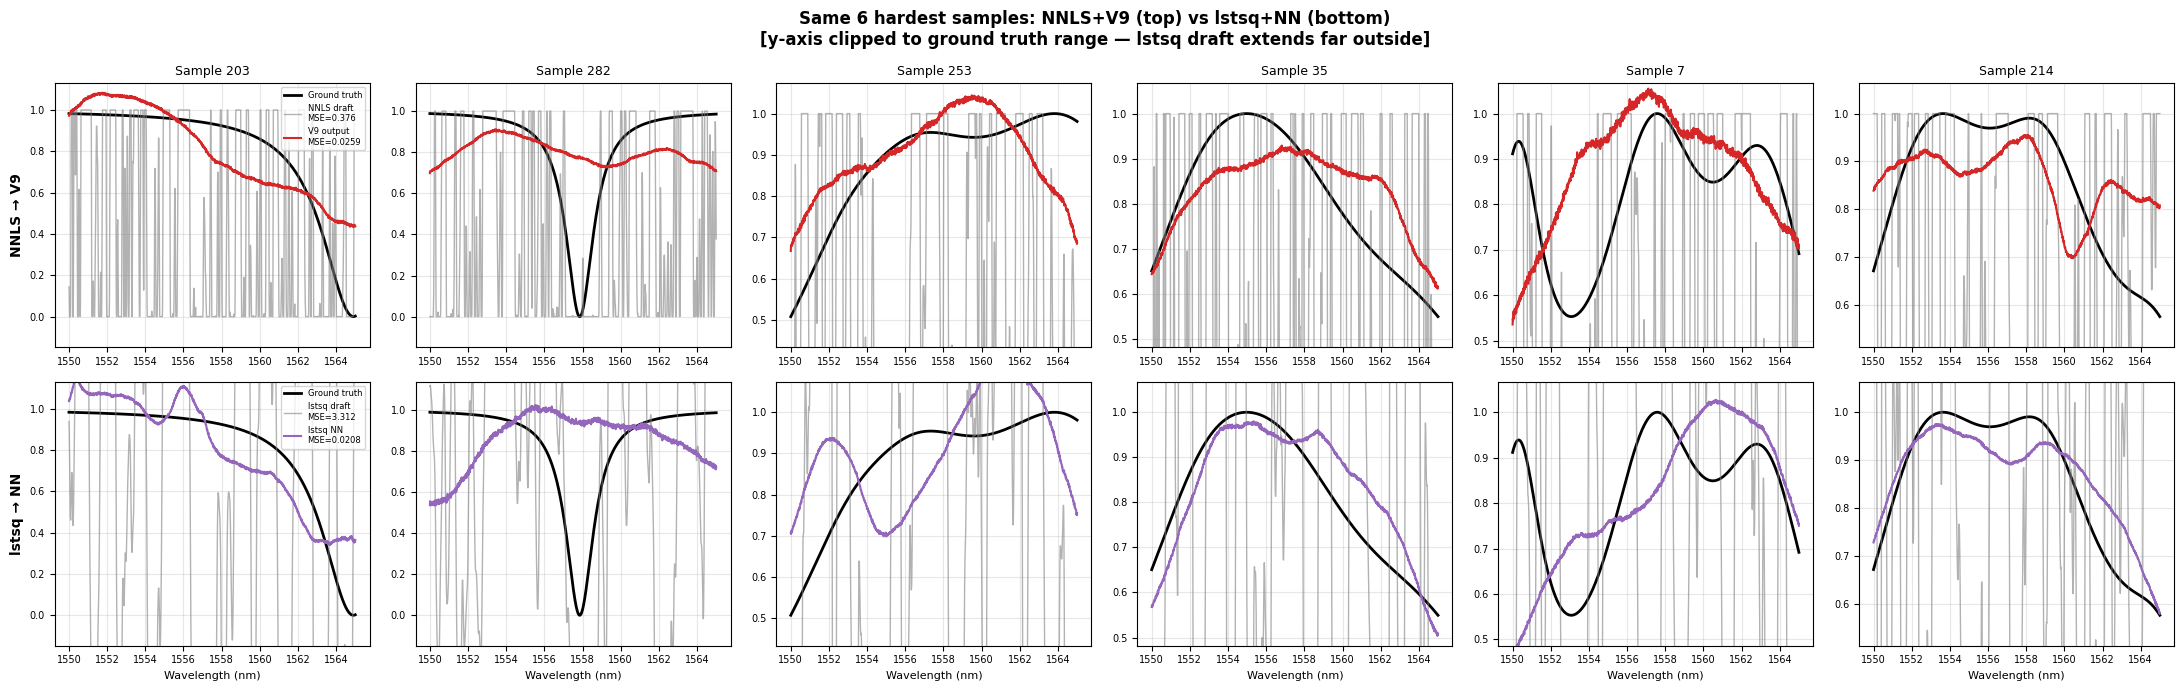

  Sample    NNLS in     V9 out    lstsq in   lstsq out    winner
-----------------------------------------------------------------
     203     0.3762     0.0259      3.3125      0.0208     lstsq
     282     0.3632     0.0606      2.3075      0.1075        V9
     253     0.3544     0.0121      2.4221      0.0230        V9
      35     0.3349     0.0091      3.0126      0.0053     lstsq
       7     0.3226     0.0294      2.7113      0.0235     lstsq
     214     0.3091     0.0148      1.4823      0.0040     lstsq

Overall: lstsq wins on 182/296 samples
Saved nnls_vs_lstsq_comparison.png


In [24]:

# --- Plot: NNLS vs lstsq side-by-side on the SAME 6 samples ---
# Top row: NNLS draft -> V9 output vs ground truth
# Bottom row: lstsq draft -> lstsq model output vs ground truth
# Y-axis clipped to ground truth range so both rows are readable.

predictions_v9     = np.load('data/predictions_v9.npy')
X_rough_nnls_test  = np.load('data/X_rough_nnls_test.npy')
y_test_loaded      = np.load('data/y_test_broad.npy')

mse_nnls_input_per  = np.mean((X_rough_nnls_test  - y_test_loaded) ** 2, axis=1)
mse_v9_per          = np.mean((predictions_v9      - y_test_loaded) ** 2, axis=1)
mse_lstsq_input_per = np.mean((X_rough_lstsq_test  - y_test_loaded) ** 2, axis=1)
mse_lstsq_out_per   = np.mean((predictions_lstsq   - y_test_loaded) ** 2, axis=1)

compare6 = np.argsort(mse_nnls_input_per)[-6:][::-1]

fig, axes = plt.subplots(2, 6, figsize=(22, 7))

for col, idx in enumerate(compare6):
    gt = y_test_loaded[idx]
    ymin = gt.min() - 0.15 * (gt.max() - gt.min() + 1e-6)
    ymax = gt.max() + 0.15 * (gt.max() - gt.min() + 1e-6)

    # --- Top row: NNLS path ---
    ax_top = axes[0, col]
    ax_top.plot(wavelengths, gt,                      color='black',   linewidth=2,   label='Ground truth')
    ax_top.plot(wavelengths, X_rough_nnls_test[idx],  color='gray',    linewidth=1,   alpha=0.6, label=f'NNLS draft\nMSE={mse_nnls_input_per[idx]:.3f}')
    ax_top.plot(wavelengths, predictions_v9[idx],     color='tab:red', linewidth=1.5, label=f'V9 output\nMSE={mse_v9_per[idx]:.4f}')
    ax_top.set_ylim(ymin, ymax)
    ax_top.set_title(f'Sample {idx}', fontsize=9)
    ax_top.grid(True, alpha=0.3)
    ax_top.tick_params(labelsize=7)
    if col == 0:
        ax_top.set_ylabel('NNLS → V9', fontsize=10, fontweight='bold')
        ax_top.legend(fontsize=6, loc='upper right')

    # --- Bottom row: lstsq path ---
    ax_bot = axes[1, col]
    ax_bot.plot(wavelengths, gt,                       color='black',      linewidth=2,   label='Ground truth')
    ax_bot.plot(wavelengths, X_rough_lstsq_test[idx],  color='gray',       linewidth=1,   alpha=0.6, label=f'lstsq draft\nMSE={mse_lstsq_input_per[idx]:.3f}')
    ax_bot.plot(wavelengths, predictions_lstsq[idx],   color='tab:purple', linewidth=1.5, label=f'lstsq NN\nMSE={mse_lstsq_out_per[idx]:.4f}')
    ax_bot.set_ylim(ymin, ymax)   # same scale as top row — lstsq draft will clip out, that's fine
    ax_bot.set_xlabel('Wavelength (nm)', fontsize=8)
    ax_bot.grid(True, alpha=0.3)
    ax_bot.tick_params(labelsize=7)
    if col == 0:
        ax_bot.set_ylabel('lstsq → NN', fontsize=10, fontweight='bold')
        ax_bot.legend(fontsize=6, loc='upper right')

fig.suptitle('Same 6 hardest samples: NNLS+V9 (top) vs lstsq+NN (bottom)\n[y-axis clipped to ground truth range — lstsq draft extends far outside]',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('nnls_vs_lstsq_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{"Sample":>8}  {"NNLS in":>9}  {"V9 out":>9}  {"lstsq in":>10}  {"lstsq out":>10}  {"winner":>8}')
print('-' * 65)
for idx in compare6:
    winner = 'lstsq' if mse_lstsq_out_per[idx] < mse_v9_per[idx] else 'V9'
    print(f'{idx:>8}  {mse_nnls_input_per[idx]:>9.4f}  {mse_v9_per[idx]:>9.4f}  {mse_lstsq_input_per[idx]:>10.4f}  {mse_lstsq_out_per[idx]:>10.4f}  {winner:>8}')
print(f'\nOverall: lstsq wins on {np.sum(mse_lstsq_out_per < mse_v9_per)}/296 samples')
print('Saved nnls_vs_lstsq_comparison.png')


## Interpreting the result

| If lstsq MSE is... | What it means | |
|---|---|---|
| **Better than V9** (< 0.0065) | NNLS spikiness was actively hurting the network "Cleaner draft helps; we should swap NNLS out" |
| **Roughly equal** (within ~5%) | The rough draft type doesn't matter much; the raw 25-d input is doing the work "NN is mostly using raw input; rough draft is decorative — try dropping it entirely" |
| **Worse than V9** | NNLS's non-negativity prior was helpful even if the output looked spiky "NNLS active set actually contributes physically meaningful information" |

